# Data Set-up and Quality Check

In [72]:
# pip install pandas numpy matplotlib statsmodels seaborn

import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
import numpy as np

In [100]:
df = pd.read_csv("Data/National_Gas_Price_Weekly.csv")
df.head()

,observation_date,GASREGW
0,1993-04-05,1.068
1,1993-04-12,1.079
2,1993-04-19,1.079
3,1993-04-26,1.086
4,1993-05-03,1.086


In [101]:
# Rename to price to make life easier

df = df.rename(columns={
    "observation_date": "Date",
    "GASREGW": "price"
})

In [102]:
# quality Check

df.head()
df.columns
df.info()
df["price"].isna().sum()
# e.g. 
# 1,724 observations (weekly data)
# 2 columns:
# Date → currently a string (needs to be datetime)
# Weekly Price → numeric (your main variable)
# No missing values

<class 'pandas.DataFrame'>
RangeIndex: 1723 entries, 0 to 1722
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    1723 non-null   str    
 1   price   1723 non-null   float64
dtypes: float64(1), str(1)
memory usage: 27.1 KB


np.int64(0)

In [103]:
# Empty row at end so dropping it
df = df.dropna()


In [104]:
# set date and set index

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")
df = df.set_index("Date")

df.head()

,price
Date,
1993-04-05,1.068
1993-04-12,1.079
1993-04-19,1.079
1993-04-26,1.086
1993-05-03,1.086


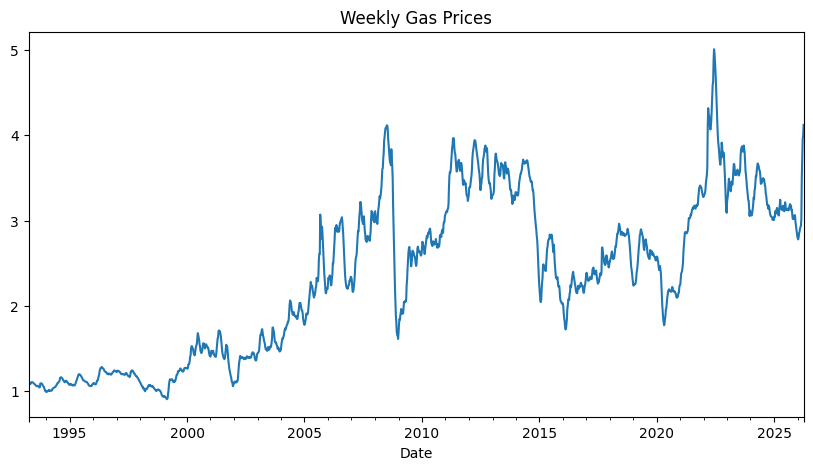

In [105]:
df["price"].plot(figsize=(10,5))
plt.title("Weekly Gas Prices")
plt.show()

In [106]:
# Random Walk with Drift Vs Deterministoc Trend; Which is it?

# ADF with constant
adf_const = adfuller(df["price"], regression="c")
print("p-value (constant):", adf_const[1])

# p ≈ 0.55 → fail to reject unit root at the 95% CL
# e.g. the series is nonstationary
# so we should difference the data

p-value (constant): 0.5252413789929653


In [107]:
# ADF with constant and trend
adf_trend = adfuller(df["price"], regression="ct")
print("p-value (trend):", adf_trend[1])

p-value (trend): 0.007541165528460474


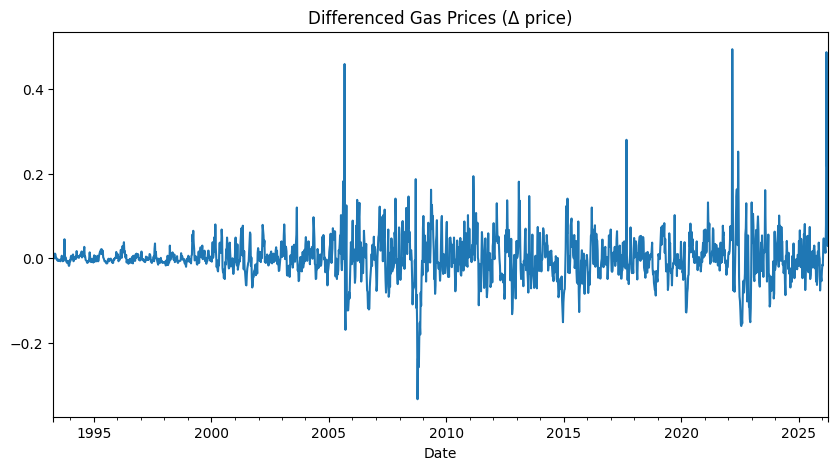

In [108]:
diff_series = df["price"].diff().dropna()

diff_series.plot(figsize=(10,5))
plt.title("Differenced Gas Prices (Δ price)")
# plt.axhline(0)  # helpful reference line
plt.show()

In [109]:
# Shows the diff series is stationary, even with heteroskedastic variance

result = adfuller(diff_series)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -10.227695735062643
p-value: 5.1251812907441186e-18


violates constant variance assumption
affects:

* standard errors

* confidence intervals

* inference 

In [ ]:
# This doesn't really help

log__price = np.log(df["price"])

# then difference
diff_log = log__price.diff()

diff_log.plot(figsize=(10,5))
plt.title("Log of Gas Prices")
plt.show()


In [110]:
# Going to start at 2000 because the data before 2000 is less simialar
df2 = df[df.index >= "2000-01-01"]

diff_series2 = df2["price"].diff().dropna()

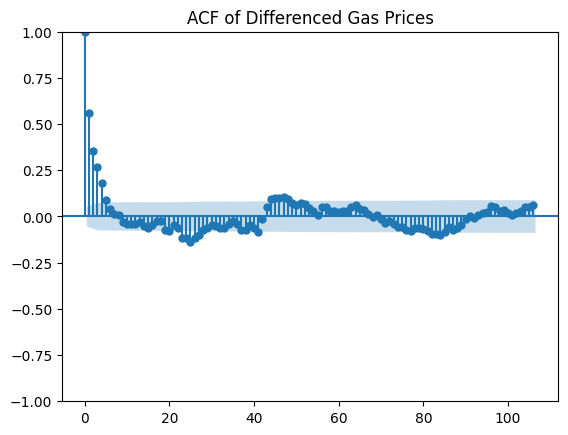

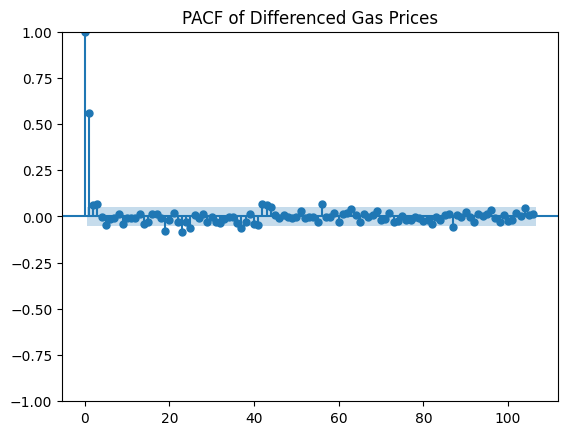

In [111]:
plot_acf(diff_series2, lags=106)
plt.title("ACF of Differenced Gas Prices")
plt.show()

plot_pacf(diff_series2, lags=106)
plt.title("PACF of Differenced Gas Prices")
plt.show()

In [112]:
# Leaving some data points off for testing the model's out-of-sample performance
train = df2.iloc[:-3].copy()
test = df2.iloc[-3:].copy()

In [113]:
orders = [(1,1,1), (2,1,1), (1,1,2)]

results_dict = {}

for order in orders:
    model = SARIMAX(df2["price"], order=order)
    res = model.fit(disp=False)

    results_dict[order] = {
        "AIC": res.aic,
        "BIC": res.bic
    }

    print(f"Order {order} -> AIC: {res.aic:.3f}, BIC: {res.bic:.3f}")

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


Order (1, 1, 1) -> AIC: -4370.071, BIC: -4354.404
Order (2, 1, 1) -> AIC: -4369.965, BIC: -4349.075
Order (1, 1, 2) -> AIC: -4371.744, BIC: -4350.853


In [114]:
# We have two models contenders based off of AIC and BIC

best_aic = min(results_dict, key=lambda x: results_dict[x]["AIC"])
best_bic = min(results_dict, key=lambda x: results_dict[x]["BIC"])

print("Best by AIC:", best_aic, results_dict[best_aic])
print("Best by BIC:", best_bic, results_dict[best_bic])

Best by AIC: (1, 1, 2) {'AIC': np.float64(-4371.743553491852), 'BIC': np.float64(-4350.853289416564)}
Best by BIC: (1, 1, 1) {'AIC': np.float64(-4370.071489982371), 'BIC': np.float64(-4354.403791925904)}


In [115]:
# Seeing which model performs better out of sample,
# This apppears to be [1, 1, 1] by a small margin

models_to_test = [(1,1,1), (1,1,2)]

from sklearn.metrics import mean_squared_error

for order in models_to_test:
    model = SARIMAX(train["price"], order=order)
    res = model.fit(disp=False)
    
    pred = res.get_forecast(steps=3).predicted_mean
    
    rmse = np.sqrt(mean_squared_error(test["price"], pred))
    
    print(f"Order {order} → RMSE: {rmse:.4f}")

Order (1, 1, 1) → RMSE: 0.0850
Order (1, 1, 2) → RMSE: 0.0985


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)


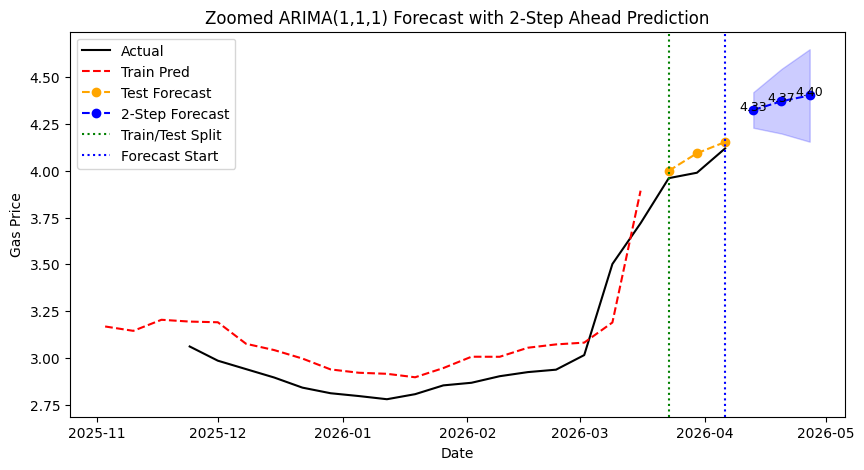

In [116]:
zoom_n = 20

plt.figure(figsize=(10,5))

# Actual (zoomed)
plt.plot(df2.index[-zoom_n:], df2["price"].iloc[-zoom_n:], 
         label="Actual", color="black")

# Train fitted (zoomed)
plt.plot(train.index[-zoom_n:], res_111.fittedvalues.iloc[-zoom_n:], 
         linestyle="--", color="red", label="Train Pred")

# Test forecast
plt.plot(test_mean.index, test_mean, 
         linestyle="--", color="orange", marker="o", label="Test Forecast")

# Future forecast (NEW)
plt.plot(future_mean.index, future_mean, 
         linestyle="--", color="blue", marker="o", label="2-Step Forecast")

# Confidence interval for future
plt.fill_between(
    future_ci.index,
    future_ci.iloc[:, 0],
    future_ci.iloc[:, 1],
    alpha=0.2,
    color="blue"
)

# Label each future point
for i, val in enumerate(future_mean):
    plt.text(
        future_mean.index[i],
        val,
        f"{val:.2f}",
        fontsize=9,
        ha='center'
    )

# Split line
plt.axvline(test.index[0], linestyle=":", color="green", label="Train/Test Split")

# Mark last observed point
plt.axvline(df2.index[-1], linestyle=":", color="blue", label="Forecast Start")

plt.title("Zoomed ARIMA(1,1,1) Forecast with 2-Step Ahead Prediction")
plt.xlabel("Date")
plt.ylabel("Gas Price")
plt.legend()
plt.show()

In [118]:
import pandas as pd

wti = pd.read_csv("Data/DCOILWTICO.csv")

# convert to datetime
wti["observation_date"] = pd.to_datetime(wti["observation_date"])

# filter from April 2021
wti_2021 = wti[wti["observation_date"] >= "2021-04-01"]

# count total rows
print("Total data points (April 2021 onward):", len(wti_2021))

Total data points (April 2021 onward): 1308
